# Act 06 — Backtest orientado a eventos de la estrategia ROC + CMF + ADX (NVDA)

Microestructura y Sistemas de Trading, ITESO. Este notebook solo importa, ejecuta y presenta:
toda la lógica vive en `src/` (`backtest.py`, `metrics.py`, `analysis.py`, `plots.py`).

**Datos:** `data/NVDA_daily.csv` recortado al fin de test (`SPLITS["test"][1]`). El periodo de
validation no se carga en este notebook; queda reservado para la evaluación final.

## 1. Resumen de la estrategia y configuración

- **Señal (SPEC §3):** long si ROC(10) > 0, CMF(20) > 0 y ADX(14) > 25; short en espejo; flat en otro caso.
  La señal se calcula al cierre de t y se ejecuta al open de t+1.
- **Salidas (SPEC §4):** SL = 2·ATR, TP = 3·ATR (r = 1.5), señal opuesta, holding máximo de 10 barras;
  gap que cruza SL/TP se llena al open; tie intrabar → SL.
- **Sizing (SPEC §5):** risk parity por ATR, ρ = 1% del capital, apalancamiento máximo 1.
- **Costos (SPEC §6):** 0.15% por lado (comisión + spread/slippage) y borrow fee de 0.5% anual en shorts.

In [1]:
from dataclasses import asdict
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

from src.analysis import break_even_cost, cost_sensitivity, sharpe_band, trade_breakdown
from src.backtest import BacktestConfig, backtest
from src.metrics import buy_and_hold_equity, drawdown_series, summarize
from src.plots import plot_cost_sensitivity, plot_drawdown, plot_equity
from src.splits import SPLITS
from src.strategy import compute_features

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

TRAIN = SPLITS["train"]
TEST = SPLITS["test"]
df = pd.read_csv("data/NVDA_daily.csv", index_col="Date", parse_dates=True).loc[:TEST[1]]
split_date = df.loc[TEST[0]:].index[0]

config = BacktestConfig()
features = compute_features(df)
result = backtest(df, features["signal"], features["atr_14"], config)
bh = buy_and_hold_equity(df, config.initial_cash, config.cost_rate)

periods = pd.DataFrame({
    "inicio": [df.loc[TRAIN[0]:TRAIN[1]].index[0], df.loc[TEST[0]:TEST[1]].index[0]],
    "fin": [df.loc[TRAIN[0]:TRAIN[1]].index[-1], df.loc[TEST[0]:TEST[1]].index[-1]],
    "barras": [len(df.loc[TRAIN[0]:TRAIN[1]]), len(df.loc[TEST[0]:TEST[1]])],
}, index=["train", "test"])
periods

,inicio,fin,barras
train,2021-09-15,2024-09-13,754
test,2024-09-16,2025-09-12,249


In [2]:
pd.Series(asdict(config), name="valor").to_frame()

,valor
initial_cash,"100,000.0000"
rho,0.0100
sl_mult,2.0000
tp_mult,3.0000
max_holding,10.0000
cost_rate,0.0015
borrow_fee_annual,0.0050


Una sola corrida del motor sobre train + test continuos (el capital y una posición abierta pasan de
train a test). Las métricas de cada periodo se calculan con `summarize(start, end)`, que rebasa la
equity al inicio del periodo. La ventana de train es la de `SPLITS` e incluye las 27 barras de
warm-up del ADX sin posición, igual para la estrategia y para buy & hold.

## 2. Validación del motor

Antes de mirar resultados, el motor se valida con tests (no se reimplementan aquí):

- **Golden test** (`tests/test_backtest.py`): escenario de 5 barras (long → TP, short → TP) con cash,
  equity por barra y borrow fee calculados a mano en `tests/golden/backtest_scenario.csv`.
- **Truncamiento** (`tests/test_truncation.py`): en 25 barras de NVDA (hasta fin de test), indicadores,
  señal y estado del backtest en t son idénticos con la serie completa y con `df.iloc[:t+1]`
  (tolerancia 1e-9). Dos **canarios** con fuga a propósito (`close.shift(-1)` y `close.shift(-2)`)
  sí fallan la comparación: el test no pasa por casualidad.
- **Métricas** (`tests/test_metrics.py`) y **análisis** (`tests/test_analysis.py`) con ejemplos chicos a mano.

In [3]:
tests = subprocess.run([sys.executable, "-m", "pytest", "tests", "-q", "--color=no"], capture_output=True, text=True)
print(tests.stdout[-400:])

........................................................................ [ 92%]
......                                                                   [100%]
78 passed in 1.04s



## 3. Curva de equity: estrategia vs buy & hold

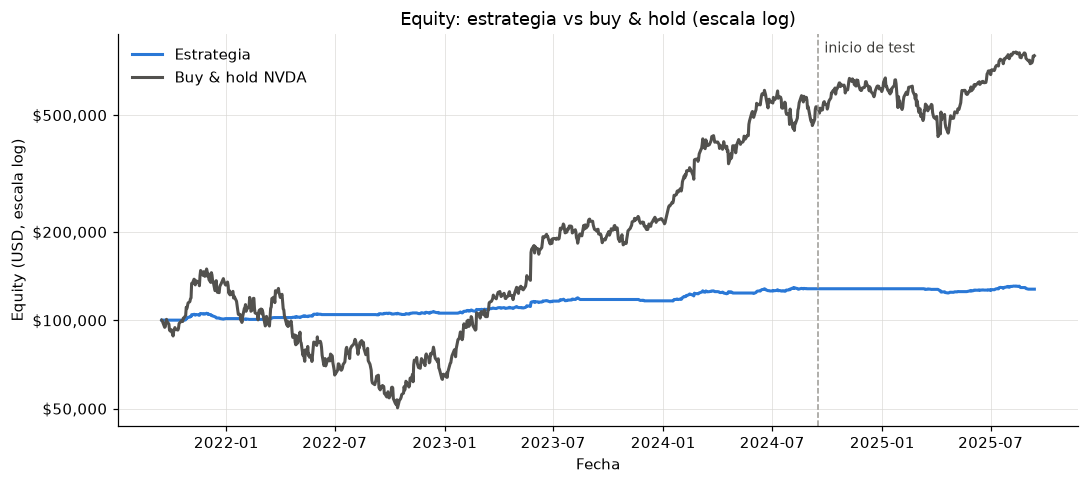

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_equity(ax, result.equity["equity"], bh["equity"], split_date)
plt.tight_layout()
plt.show()

## 4. Drawdown sobre el capital

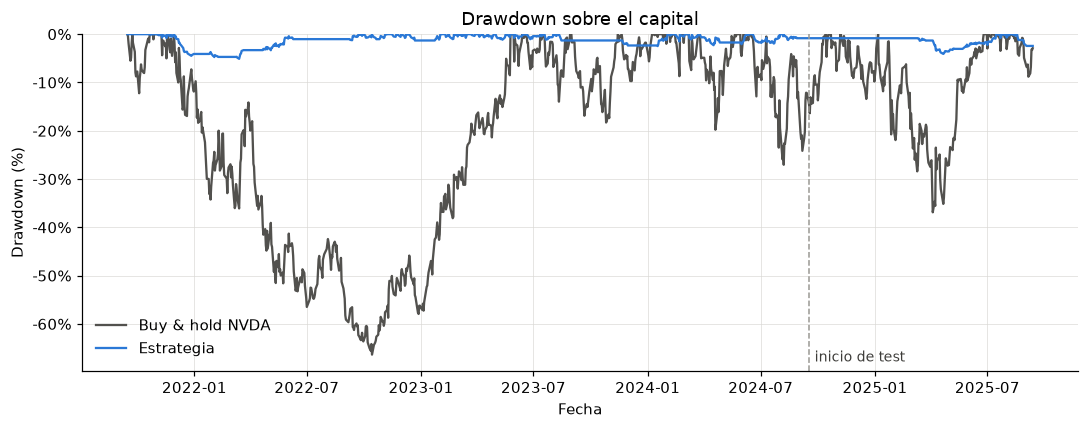

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_drawdown(ax, drawdown_series(result.equity["equity"]), drawdown_series(bh["equity"]), split_date)
plt.tight_layout()
plt.show()

## 5. Lista de operaciones

In [6]:
trades = result.trades
trades[["entry_date", "exit_date", "side", "shares", "raw_entry_price", "raw_exit_price",
        "exit_reason", "borrow_fee", "pnl"]].head(10)

,entry_date,exit_date,side,shares,raw_entry_price,raw_exit_price,exit_reason,borrow_fee,pnl
0,2021-10-22,2021-10-26,long,887,22.8230,24.5132,take_profit,0.0000,"1,436.1847"
1,2021-10-27,2021-11-02,long,748,24.4740,26.5060,take_profit,0.0000,"1,462.7522"
2,2021-11-03,2021-11-04,long,742,26.6700,28.7499,take_profit,0.0000,"1,481.6266"
3,2021-11-05,2021-11-18,long,535,30.1870,31.6750,max_holding,0.0000,746.4352
4,2021-11-19,2021-12-03,long,380,32.2430,30.6930,max_holding,0.0000,-624.8732
5,2021-12-06,2021-12-08,short,330,29.8800,31.9990,opposite_signal,0.2739,-730.1745
6,2021-12-08,2021-12-13,long,303,31.9990,28.5744,stop_loss,0.0000,"-1,065.1799"
7,2021-12-14,2021-12-16,short,303,27.6990,31.1520,stop_loss,0.2331,"-1,073.2402"
8,2021-12-17,2021-12-31,short,276,27.9850,29.4110,max_holding,1.5019,-418.8394
9,2022-01-26,2022-02-08,short,333,23.2400,25.1080,max_holding,1.3973,-647.5911


In [7]:
print(f"Trades cerrados: {len(trades)}")
print(f"Trades truncados por el tope de apalancamiento: {int(trades['truncated'].sum())}")
print(f"Borrow fee total: ${trades['borrow_fee'].sum():,.2f}")
print(f"Posición abierta al final de test: {int(result.equity['shares'].iloc[-1])} acciones")
pd.crosstab(trades["exit_reason"], trades["side"], margins=True, margins_name="total")

Trades cerrados: 74
Trades truncados por el tope de apalancamiento: 0
Borrow fee total: $25.05
Posición abierta al final de test: 0 acciones


side,long,short,total
exit_reason,,,
max_holding,26,8,34
opposite_signal,2,5,7
stop_loss,8,6,14
take_profit,15,4,19
total,51,23,74


In [8]:
pd.concat({"train": trade_breakdown(trades, *TRAIN), "test": trade_breakdown(trades, *TEST)})

n_trades   total_pnl     avg_pnl  win_rate
      side                                             
train long         42 27,156.3033    646.5786    0.6905
      short        20    766.2254     38.3113    0.4000
test  long          9  2,782.1244    309.1249    0.6667
      short         3 -3,193.7993 -1,064.5998    0.0000

## 6. Métricas por periodo

Rangos de clase para el Sharpe: < 1 malo, 1–2 bueno, > 2 excelente, > 3 probable error.

In [9]:
no_trades = trades.iloc[0:0]
metrics = pd.DataFrame({
    "estrategia train": summarize(result.equity, trades, config, *TRAIN),
    "estrategia test": summarize(result.equity, trades, config, *TEST),
    "buy & hold train": summarize(bh, no_trades, config, *TRAIN),
    "buy & hold test": summarize(bh, no_trades, config, *TEST),
})
display(metrics)
metrics.loc["sharpe"].map(lambda s: f"{s:.2f} → {sharpe_band(s)}").to_frame("Sharpe (rango de clase)")

,estrategia train,estrategia test,buy & hold train,buy & hold test
equity_final,"127,922.5287","99,678.1842","533,024.8874","152,267.4842"
total_return,0.2792,-0.0032,4.3302,0.5227
cagr,0.0859,-0.0033,0.7507,0.5330
sharpe,1.6670,-0.0875,1.2680,1.1075
sortino,3.1899,-0.1159,2.0242,1.5979
max_drawdown,-0.0510,-0.0328,-0.6635,-0.3689
calmar,1.6830,-0.0998,1.1314,1.4451
n_trades,62.0000,12.0000,0.0000,0.0000
trades_per_year,20.7490,12.1935,0.0000,0.0000
avg_pnl,450.3634,-34.3062,NaN,NaN


,Sharpe (rango de clase)
estrategia train,1.67 → bueno
estrategia test,-0.09 → malo
buy & hold train,1.27 → bueno
buy & hold test,1.11 → bueno


## 7. Win rate teórico vs empírico

p* = 1/(1+r) con r = TP/SL = 1.5. Con costos, p* = (1+k)/(1+r), con k = costo ida y vuelta / riesgo
(2·ATR·Q) promedio de los trades del periodo.

In [10]:
metrics.loc[["win_rate", "p_star", "k_mean", "p_star_cost"], ["estrategia train", "estrategia test"]]

,estrategia train,estrategia test
win_rate,0.5968,0.5000
p_star,0.4000,0.4000
k_mean,0.0381,0.0431
p_star_cost,0.4152,0.4172


## 8. Sensibilidad a costos

Costo de ida y vuelta de 0 a 50 bps (cost_rate = bps / 2 / 10 000); el borrow fee no cambia.
Costo asumido en el SPEC: 2 × 15 bps = 30 bps.

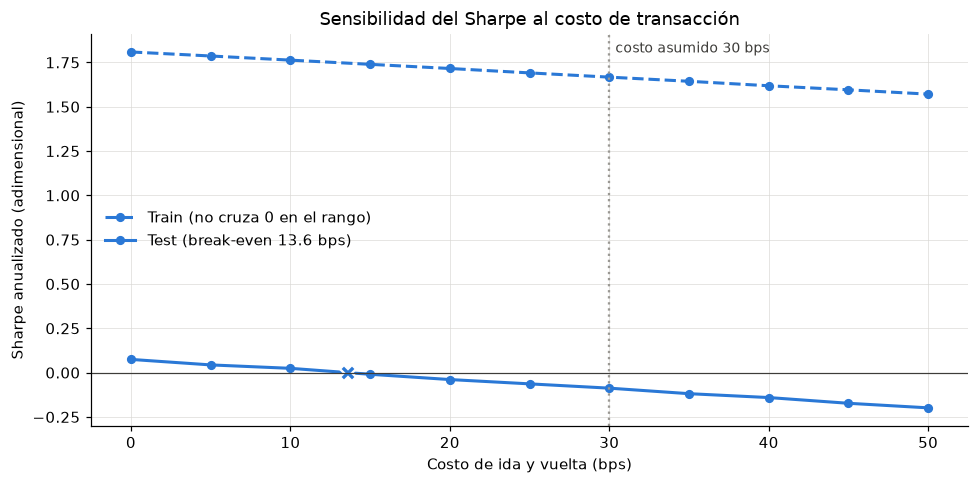

{'train': 'no cruza 0 entre 0 y 50 bps', 'test': '13.6 bps'}


,sharpe_train,equity_final_train,sharpe_test,equity_final_test
bps,,,,
0,1.8090,"130,931.4185",0.0746,"100,182.9717"
5,1.7863,"130,446.2094",0.0436,"100,086.5328"
10,1.7630,"129,941.8973",0.0243,"100,026.5694"
15,1.7392,"129,425.9082",-0.0092,"99,922.3404"
20,1.7158,"128,929.7134",-0.0390,"99,829.7546"
25,1.6909,"128,420.0505",-0.0633,"99,754.2409"
30,1.6670,"127,922.5287",-0.0875,"99,678.1842"
35,1.6436,"127,432.7261",-0.1187,"99,581.5629"
40,1.6183,"126,922.0036",-0.1406,"99,513.4037"


In [11]:
sensitivity = cost_sensitivity(df, config)
break_even = {p: break_even_cost(sensitivity.index, sensitivity[f"sharpe_{p}"]) for p in ["train", "test"]}

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_cost_sensitivity(ax, sensitivity, assumed_bps=30, break_even=break_even)
plt.tight_layout()
plt.show()

print({p: (f"{v:.1f} bps" if pd.notna(v) else "no cruza 0 entre 0 y 50 bps") for p, v in break_even.items()})
sensitivity

## 9. Auditoría de sesgos

In [12]:
by_side = {p: trade_breakdown(trades, *SPLITS[p]) for p in ["train", "test"]}
fmt_side = lambda p: (f"{p}: longs ${by_side[p].loc['long', 'total_pnl']:,.0f} "
                      f"({by_side[p].loc['long', 'n_trades']} trades), shorts "
                      f"${by_side[p].loc['short', 'total_pnl']:,.0f} ({by_side[p].loc['short', 'n_trades']} trades)")
be_test = break_even["test"]
sharpe = metrics.loc["sharpe"]

audit = pd.DataFrame([
    ("Look-ahead",
     "test_truncation.py: 25 barras × (features + backtest) = 50 casos idénticos con df.iloc[:t+1]; "
     "canarios shift(-1) y shift(-2) fallan en 18/25 y 16/25 barras. backtest.py ejecuta en t la señal "
     "y el ATR de t-1 (open de t+1 respecto a la señal). Correlación de features solo en train "
     "(data/indicator_analysis.py).",
     "mitigado"),
    ("Survivorship",
     f"Un solo activo (NVDA) elegido ex-post, que sobrevivió y fue de los mejores del periodo: buy & hold "
     f"{metrics.loc['total_return', 'buy & hold train']:+.0%} en train y "
     f"{metrics.loc['total_return', 'buy & hold test']:+.0%} en test. El benchmark es el mismo activo, así "
     f"que la comparación no corrige este sesgo.",
     "presente"),
    ("Overfitting / data snooping",
     "Umbrales de literatura (0 en ROC/CMF, ADX 25 de Wilder, SL/TP 2/3 ATR), sin búsqueda de parámetros; "
     "selección de features por correlación solo en train. Declaración: durante el desarrollo se vieron "
     "resultados del periodo completo (incluida validation) en corridas de prueba, aunque nada se ajustó "
     f"con ellos. Sharpe train {sharpe['estrategia train']:.2f} vs test {sharpe['estrategia test']:.2f}.",
     "parcial"),
    ("Ejecución optimista",
     f"Costos 15 bps/lado, gap llena al open, tie → SL, borrow fee (${trades['borrow_fee'].sum():,.0f} total). "
     "Sigue siendo optimista: llenado exacto al open y sin límite de volumen. Break-even de costos: train "
     + ("no cruza 0 hasta 50 bps" if pd.isna(break_even['train']) else f"{break_even['train']:.1f} bps")
     + f"; test {be_test:.1f} bps, por debajo de los 30 bps asumidos.",
     "parcial"),
    ("Selección / periodo de muestra",
     "2021-2025 con NVDA mayormente alcista. " + fmt_side("train") + "; " + fmt_side("test")
     + ". Los longs explican casi todo el P&L.",
     "presente"),
], columns=["sesgo", "evidencia", "estado"]).set_index("sesgo")

audit.style.set_properties(**{"text-align": "left", "white-space": "normal"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}])

,evidencia,estado
sesgo,,
Look-ahead,test_truncation.py: 25 barras × (features + backtest) = 50 casos idénticos con df.iloc[:t+1]; canarios shift(-1) y shift(-2) fallan en 18/25 y 16/25 barras. backtest.py ejecuta en t la señal y el ATR de t-1 (open de t+1 respecto a la señal). Correlación de features solo en train (data/indicator_analysis.py).,mitigado
Survivorship,"Un solo activo (NVDA) elegido ex-post, que sobrevivió y fue de los mejores del periodo: buy & hold +433% en train y +52% en test. El benchmark es el mismo activo, así que la comparación no corrige este sesgo.",presente
Overfitting / data snooping,"Umbrales de literatura (0 en ROC/CMF, ADX 25 de Wilder, SL/TP 2/3 ATR), sin búsqueda de parámetros; selección de features por correlación solo en train. Declaración: durante el desarrollo se vieron resultados del periodo completo (incluida validation) en corridas de prueba, aunque nada se ajustó con ellos. Sharpe train 1.67 vs test -0.09.",parcial
Ejecución optimista,"Costos 15 bps/lado, gap llena al open, tie → SL, borrow fee ($25 total). Sigue siendo optimista: llenado exacto al open y sin límite de volumen. Break-even de costos: train no cruza 0 hasta 50 bps; test 13.6 bps, por debajo de los 30 bps asumidos.",parcial
Selección / periodo de muestra,"2021-2025 con NVDA mayormente alcista. train: longs $27,156 (42 trades), shorts $766 (20 trades); test: longs $2,782 (9 trades), shorts $-3,194 (3 trades). Los longs explican casi todo el P&L.",presente


## 10. Conclusiones

Dos cálculos de apoyo: el tamaño promedio de posición (nocional al entrar como % de la equity en la
barra de entrada) y el error estándar del win rate de test.

In [13]:
from src.analysis import position_size, win_rate_standard_error

size = pd.Series({p: position_size(trades, result.equity, *SPLITS[p]) for p in ["train", "test"]},
                 name="tamaño promedio (% del capital)")
display((size * 100).round(1).to_frame())

n_test = int(metrics.loc["n_trades", "estrategia test"])
p_test = metrics.loc["win_rate", "estrategia test"]
se = win_rate_standard_error(p_test, n_test)
print(f"Win rate test = {p_test:.1%} con n = {n_test}: error estándar = {se:.1%}; "
      f"IC 95% ≈ [{p_test - 1.96 * se:.0%}, {p_test + 1.96 * se:.0%}]; "
      f"distancia a 40% = {(p_test - 0.40) / se:.2f} errores estándar")

,tamaño promedio (% del capital)
train,12.4000
test,14.1000


Win rate test = 50.0% con n = 12: error estándar = 14.4%; IC 95% ≈ [22%, 78%]; distancia a 40% = 0.69 errores estándar


- **¿Le gana a buy & hold?** No en rendimiento: en train la estrategia hace +28% (CAGR 8.6%) contra
  +433% de buy & hold, y en test −0.3% contra +52%. En train sí tiene mejor rendimiento ajustado por
  riesgo (Sharpe 1.67 vs 1.27; max drawdown −5.1% vs −66%). En test pierde también en Sharpe
  (−0.09 vs 1.11). Parte de la diferencia en rendimiento viene de dos cosas distintas:
  - **Exposición:** la estrategia tiene posición abierta solo el 52% de las barras de train (33% en
    test), contra 100% de buy & hold.
  - **Tamaño:** cuando opera, el nocional promedio es solo ~12.4% del capital en train y ~14.1% en
    test (tabla de arriba). Es consecuencia directa del sizing: Q·P/V = ρ / (2·ATR/P). Con ρ = 1% y un
    ATR de NVDA de ~4.5% del precio en las entradas, eso da 0.01 / 0.09 ≈ 11% del capital. Arriesgar
    1% del capital con un stop a 2·ATR limita el tamaño, aunque el tope de apalancamiento 1 nunca se
    activa (0 trades truncados).
- **¿Supera p\*?** El win rate empírico supera el break-even con costos en ambos periodos
  (train 59.7% vs 41.5%; test 50.0% vs 41.7%). Aun así, el profit factor en test es 0.94: p\* supone
  que cada trade sale por SL o TP (−1 R o +1.5 R), pero 34 de los 74 trades de train + test salen
  por holding máximo, con pagos intermedios. Superar p\* no basta si las salidas no realizan el r supuesto.
- **¿Es robusta a costos?** En train sí: el Sharpe baja de 1.81 a 1.57 entre 0 y 50 bps y no cruza 0.
  En test no: el break-even es ~13.6 bps de ida y vuelta, por debajo de los 30 bps asumidos, así que
  ya con costos realistas el Sharpe de test es negativo.
- **¿Señales de overfitting?** Hay una caída fuerte de train a test (Sharpe 1.67 → −0.09). No hubo
  ajuste de parámetros, así que la caída no viene de optimizar sobre train, pero el periodo de train
  fue muy favorable para longs. Test tiene solo 12 trades y la pérdida la explican 3 shorts
  (−$3,194), así que la muestra es chica para concluir. La evidencia apunta más a dependencia del
  régimen alcista (sesgo de selección del activo y del periodo) que a sobreajuste de parámetros.
  Además, con 12 trades el win rate de test no es estadísticamente distinguible de p\* = 40%: el
  error estándar es sqrt(p(1−p)/n) = sqrt(0.5·0.5/12) ≈ 14.4 pp, así que el IC 95% de 50% es
  aproximadamente [22%, 78%] y 40% está a solo 0.69 errores estándar.